## Lab 12 – OpenCV Basics (Image Processing)

## Task 1: Read, Display, Save
- • Read an image
- • Display it
- • Convert to grayscale
- • Save the grayscale image as output_gray.jpg

In [3]:
#Importing the required libraries 
import cv2
import numpy as np

In [7]:
# Task 1 q1 - Read an image
img = cv2.imread("image.jpg")

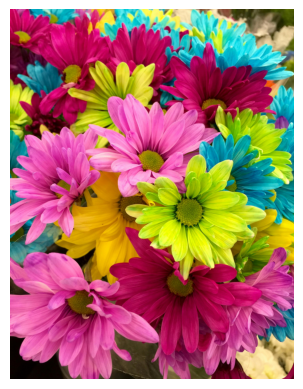

In [ ]:
import cv2
from matplotlib import pyplot as plt

# Display the image 
plt.imshow(img_rgb)
plt.axis("off")
plt.show()


- Convert the image to grayscale and save the output

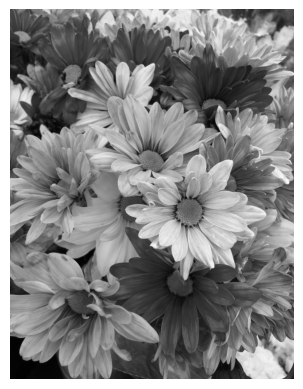

In [3]:
import cv2
from matplotlib import pyplot as plt

# Reading the image
img = cv2.imread("image.jpg")

# Convert BLUE GREEN RED IMAGE INTO Gray 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Save output
cv2.imwrite("output_gray.jpg", gray)

# Show in notebook
plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()


## Task 2: Extract and Visualize Color Channels
For any image:
- • Extract Blue, Green, Red channels
- • Display each channel separately
- • Create an image showing only green colors

In [8]:
# Extract blue,green, red channels
blue = img[:, :, 0]   # all rows , all columns, channel 0 (Blue)
green = img[:, :, 1]  # channel 1 (Green)
red = img[:, :, 2]    # channel 2 (Red)


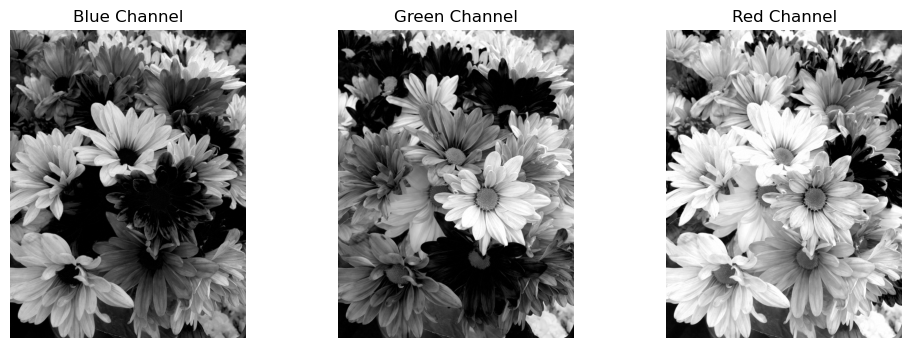

In [ ]:
# Displaying each channel separatley
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Blue Channel")
plt.imshow(blue, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Green Channel")
plt.imshow(green, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Red Channel")
plt.imshow(red, cmap='gray')
plt.axis("off")

plt.show()


In [ ]:
# Removing the red and blue color to display only green
only_green = img.copy()
only_green[:, :, 0] = 0   # Remove blue color
only_green[:, :, 2] = 0   # Remove red color


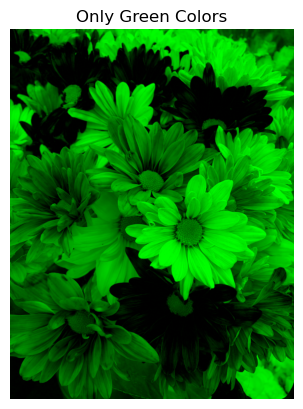

In [ ]:
# Display the image showing only green color
only_green_rgb = cv2.cvtColor(only_green, cv2.COLOR_BGR2RGB)

plt.imshow(only_green_rgb)
plt.title("Only Green Colors")
plt.axis("off")
plt.show()


## Task 3: Color Space Conversions
Convert the image to:
- • RGB
- • HSV
- • Grayscale
Display all three.

In [10]:
# Import all the req libraries and define all the parameters

import cv2
from matplotlib import pyplot as plt
import os

# All the parameters already defined
input_path = "image.jpg"
save_rgb = "output_rgb.jpg"
save_hsv = "output_hsv.jpg"
save_gray = "output_gray.jpg"


In [11]:
# Read the image and check its loaded or not
img = cv2.imread(input_path)
if img is None:
    raise FileNotFoundError(f"Could not read '{input_path}'. Put the image in the same folder as this notebook or give a full path.")
print("Image shape (H, W, C):", img.shape)


Image shape (H, W, C): (3196, 2448, 3)


## Convering to RGB

In [12]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


## Converting to HSV

In [13]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)      # raw HSV array
hsv_visual = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)  # convert back to RGB for human  readable viewing


## Converting to Grayscale

In [14]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


## Saving all the images

In [15]:
cv2.imwrite(save_rgb, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))   # convert back to BGR for correct file colors
cv2.imwrite(save_hsv, cv2.cvtColor(hsv_visual, cv2.COLOR_RGB2BGR))
cv2.imwrite(save_gray, img_gray)

print("Saved:", os.path.abspath(save_rgb))
print("Saved:", os.path.abspath(save_hsv))
print("Saved:", os.path.abspath(save_gray))


Saved: c:\Users\PC\Desktop\AI Labs Final\ai lab 12\output_rgb.jpg
Saved: c:\Users\PC\Desktop\AI Labs Final\ai lab 12\output_hsv.jpg
Saved: c:\Users\PC\Desktop\AI Labs Final\ai lab 12\output_gray.jpg


## Displaying the images

(-0.5, 2447.5, 3195.5, -0.5)

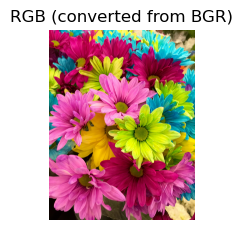

In [16]:
# RGB
plt.subplot(1,3,1); plt.title("RGB (converted from BGR)"); plt.imshow(img_rgb); plt.axis("off")


(-0.5, 2447.5, 3195.5, -0.5)

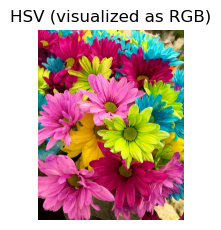

In [20]:
# HSV
plt.subplot(1,3,2); plt.title("HSV (visualized as RGB)"); plt.imshow(hsv_visual); plt.axis("off")


(-0.5, 2447.5, 3195.5, -0.5)

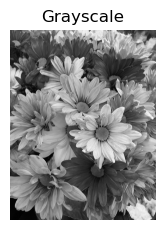

In [21]:
# Grayscale
plt.subplot(1,3,3); plt.title("Grayscale"); plt.imshow(img_gray, cmap='gray'); plt.axis("off")


## Task 4: Region Extraction (ROI)
- • Extract a rectangular region from the image
- • Save it as roi_image.jpg
- • Resize it to 200×200 pixels

In [22]:
# ROI Coordinates
x1, y1 = 50, 50      
x2, y2 = 250, 250

print("ROI coordinates:", x1, y1, x2, y2)


ROI coordinates: 50 50 250 250


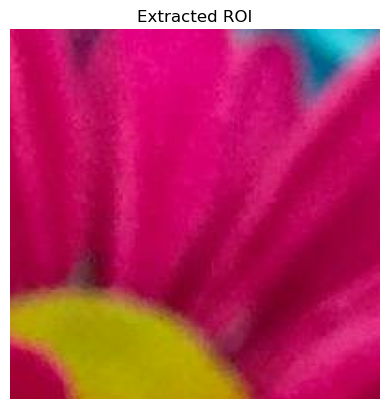

In [23]:
# Extract a rectangular region
roi = img[y1:y2, x1:x2]

plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("Extracted ROI")
plt.axis("off")
plt.show()


In [ ]:
# Save the rectangular region
cv2.imwrite("roi_image.jpg", roi)


True

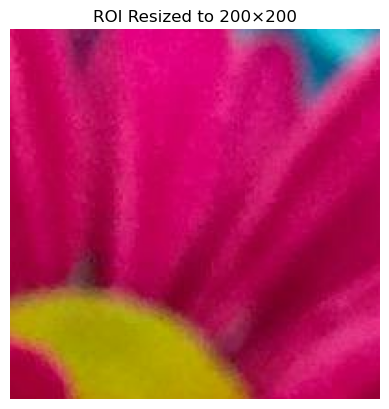

In [ ]:
# Resize to 200 x  200 Pixels
roi_resized = cv2.resize(roi, (200, 200))

plt.imshow(cv2.cvtColor(roi_resized, cv2.COLOR_BGR2RGB))
plt.title("ROI Resized to 200×200")
plt.axis("off")
plt.show()


In [26]:
# Saving the resized roi
cv2.imwrite("roi_resized_200x200.jpg", roi_resized)


True

## Task 5: Simple Computer Vision Mask
Using HSV:
- • Detect and extract only red color objects in the image
- (Hint: use cv2.inRange)

In [27]:
# Convert the image into HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


In [28]:
# Define the color ranges
# Lower And Upper


# Lower red range
lower_red1 = (0, 100, 100)
upper_red1 = (10, 255, 255)

# Upper red range
lower_red2 = (170, 100, 100)
upper_red2 = (180, 255, 255)


In [29]:
# Creating the masks using opencv2
mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

# Combine both masks
red_mask = mask1 + mask2


In [30]:
# Extracting only red objects
red_objects = cv2.bitwise_and(img_rgb, img_rgb, mask=red_mask)


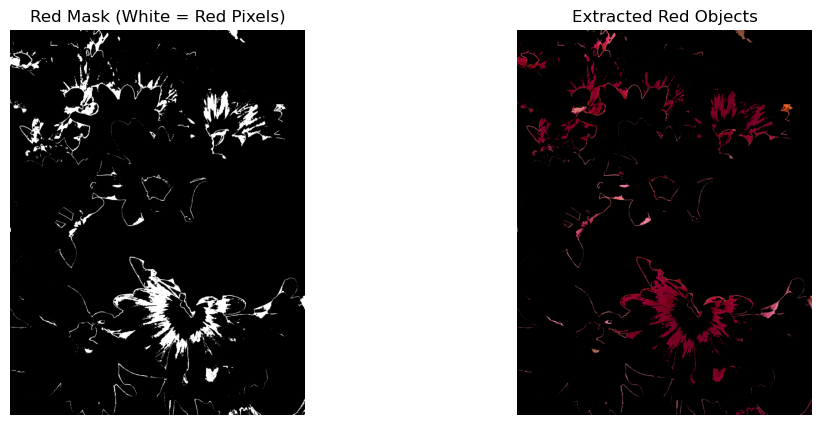

In [32]:
# Displaying the image (Red objects color only)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Red Mask (White = Red Pixels)")
plt.imshow(red_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Extracted Red Objects")
plt.imshow(red_objects)
plt.axis("off")

plt.show()


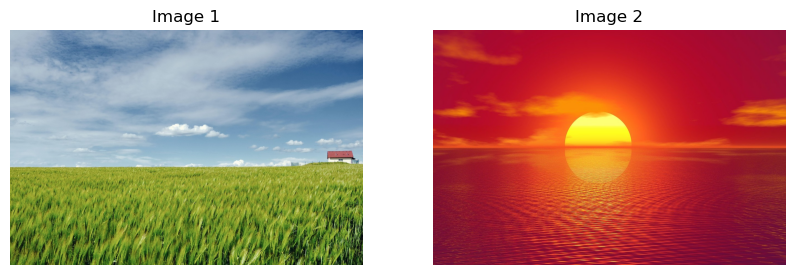

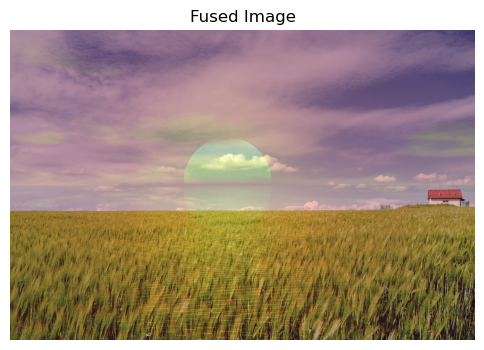

True

In [1]:
import cv2
import matplotlib.pyplot as plt

# Read two images (already uploaded in your Jupyter notebook)
img1 = cv2.imread("image1.jpg")
img2 = cv2.imread("image2.jpg")

# Convert BGR → RGB for Jupyter display
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Resize second image to match first image size
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Display the two input images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")

plt.show()

# Weighted addition (image fusion)
alpha = 0.7
beta  = 0.3
gamma = 0

fused = cv2.addWeighted(img1, alpha, img2, beta, gamma)

# Display fused image
plt.figure(figsize=(6,6))
plt.imshow(fused)
plt.title("Fused Image")
plt.axis("off")
plt.show()

# Save fused image
cv2.imwrite("fused_output.jpg", cv2.cvtColor(fused, cv2.COLOR_RGB2BGR))
